In [8]:
!pip install "numpy<2"

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [9]:
import pandas as pd
import numpy as np

def generate_data(save_path="dc_raw_data.csv"):
    times = pd.date_range(start="2025-01-01", end="2025-12-31 23:59", freq="1min")
    n = len(times)
    
    # Base seasonality (Daily and Yearly)
    day_sin = np.sin(2 * np.pi * times.hour / 24)
    year_cos = np.cos(2 * np.pi * times.dayofyear / 365)
    
    # Features
    solar = np.maximum(0, 800 * day_sin + np.random.normal(0, 50, n))
    temp_out = 20 + 10 * year_cos + 5 * day_sin + np.random.normal(0, 1, n)
    it_load = 500 + 200 * np.abs(day_sin) + np.random.normal(0, 30, n)
    # Cooling power roughly follows IT load and outside temp
    cooling_pw = (it_load * 0.3) + (temp_out * 2) + np.random.normal(0, 10, n)
    
    df = pd.DataFrame({
        'timestamp': times,
        'solar_irradiance': solar,
        'temp_out': temp_out,
        'it_load_kw': it_load,
        'cooling_kw': cooling_pw
    })
    
    # Simulate sensor drops (5% of data goes missing)
    mask = np.random.choice([True, False], size=df.shape, p=[0.05, 0.95])
    df[mask] = np.nan
    df['timestamp'] = times # Keep timestamps intact
    
    df.to_csv(save_path, index=False)
    print(f"Dataset generated: {df.shape[0]} rows.")

if __name__ == "__main__":
    generate_data()

Dataset generated: 525600 rows.


                     solar_irradiance   temp_out  it_load_kw  cooling_kw
timestamp                                                               
2025-01-01 00:00:00          0.000000  29.884558  468.314146  206.314269
2025-01-01 00:01:00         33.168701  31.214547  486.826116  198.326715
2025-01-01 00:02:00          0.000000  30.796012  516.403223  217.475431
2025-01-01 00:03:00          1.537611  30.354392  541.529471  205.342403
2025-01-01 00:04:00         67.687414  29.692689  540.287108  215.652267


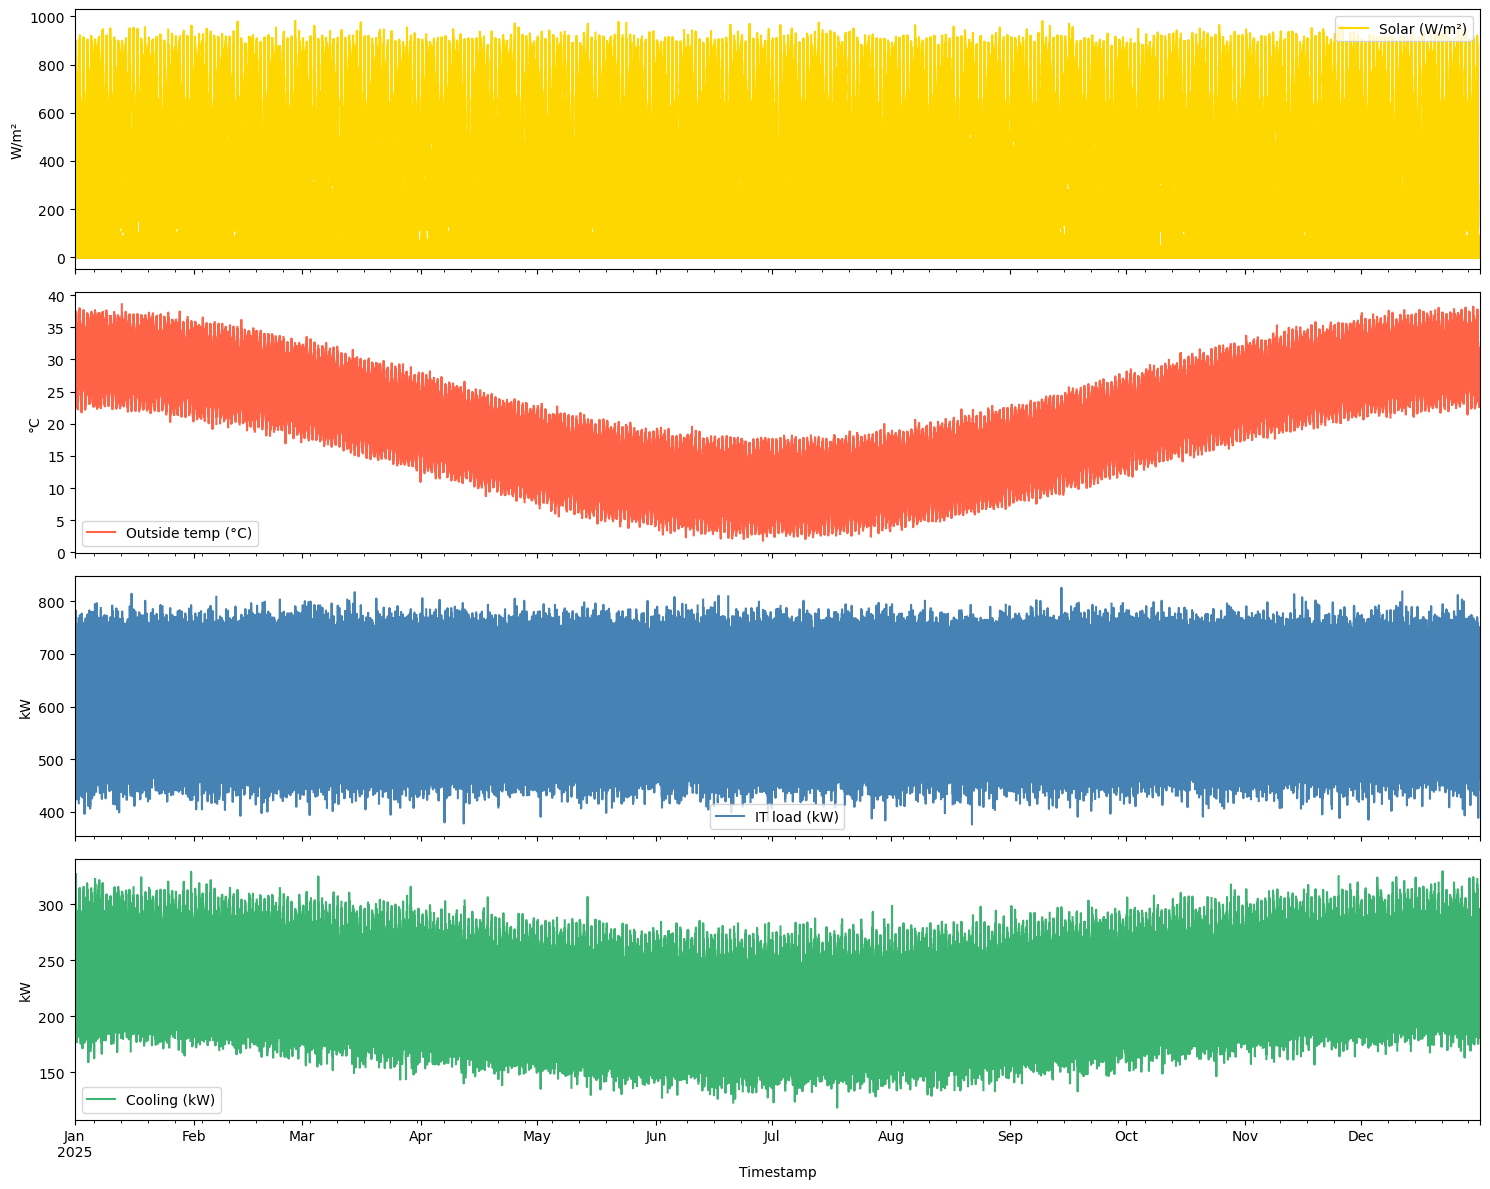

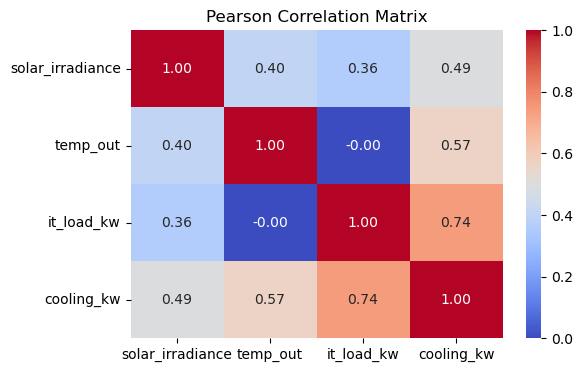

In [10]:
# Visualizing data
# !pip install pandas matplotlib seaborn plotly

import pandas as pd

df = pd.read_csv('dc_raw_data.csv', parse_dates=['timestamp'])
df.set_index('timestamp', inplace=True)

print(df.head())

import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Raw time‑series (one subplot per column) -----------------
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(15, 12), sharex=True)

df['solar_irradiance'].plot(ax=axes[0], color='gold', label='Solar (W/m²)')
axes[0].set_ylabel('W/m²')
axes[0].legend()

df['temp_out'].plot(ax=axes[1], color='tomato', label='Outside temp (°C)')
axes[1].set_ylabel('°C')
axes[1].legend()

df['it_load_kw'].plot(ax=axes[2], color='steelblue', label='IT load (kW)')
axes[2].set_ylabel('kW')
axes[2].legend()

df['cooling_kw'].plot(ax=axes[3], color='mediumseagreen', label='Cooling (kW)')
axes[3].set_ylabel('kW')
axes[3].legend()

plt.xlabel('Timestamp')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pearson Correlation Matrix')
plt.show()


In [11]:
import pandas as pd

def clean_data(input_path="dc_raw_data.csv", output_path="dc_cleaned_data.csv"):
    df = pd.read_csv(input_path, parse_dates=['timestamp'])
    
    # Forward fill then backward fill to ensure no NaNs remain
    df_cleaned = df.interpolate(method='linear').ffill().bfill()
    
    df_cleaned.to_csv(output_path, index=False)
    print("Data cleaned and interpolated.")

if __name__ == "__main__":
    clean_data()

Data cleaned and interpolated.


In [13]:
#!pip install tensorflow
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
import joblib

#def train_deep_learning_model(input_path="dc_cleaned_data.csv", model_path="it_load_cnn_lstm.h5"):
def train_deep_learning_model(input_path="dc_cleaned_data.csv", model_path="it_load_cnn_lstm.keras"):
    # 1. Load and Scale Data
    df = pd.read_csv(input_path)
    features = ['solar_irradiance', 'temp_out', 'it_load_kw']
    data = df[features].values
    
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    
    # 2. Create Sliding Windows (3D Shape for Deep Learning)
    # Shape: (N samples, 30 time steps, 3 features)
    X, y = [], []
    window_size = 30
    for i in range(window_size, len(scaled_data)):
        X.append(scaled_data[i-window_size:i])
        y.append(scaled_data[i, 2]) # Predicting 'it_load_kw'
    
    X, y = np.array(X), np.array(y)
    
    # Split into Train/Test
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Build the Hybrid 1D-CNN + LSTM Model
    model = models.Sequential([
        # Modern Keras standard: Explicit Input layer
        layers.Input(shape=(window_size, 3)),
        
        # CNN: Slides over 3-minute chunks to find local patterns (spikes)
        layers.Conv1D(filters=32, kernel_size=3, activation='relu'),
        layers.MaxPooling1D(pool_size=2),
        
        # LSTM: Processes the "high-level" features from the CNN
        layers.LSTM(64, return_sequences=False),
        
        # Dense layers for the final prediction
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])

    # model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss=tf.keras.losses.MeanSquaredError(),
        metrics=[tf.keras.metrics.MeanAbsoluteError()]
    )
    
    # 4. Train the Model
    print("Training CNN-LSTM Model...")
    # Using 5 epochs for a "minimum working example" so it runs fast in class
    model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.1, verbose=1)
    
    # 5. Save the model and the scaler
    # Note: .h5 or .keras is the standard format for TF models
    model.save(model_path)
    joblib.dump(scaler, "scaler.pkl")
    
    # Evaluate
    loss, mae = model.evaluate(X_test, y_test, verbose=0)
    print(f"Model Training Complete. Test MAE: {mae:.4f}")
    
    return model

if __name__ == "__main__":
    train_deep_learning_model()

Training CNN-LSTM Model...
Epoch 1/5
11826/11826 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 0.0053 - mean_absolute_error: 0.0572 - val_loss: 0.0048 - val_mean_absolute_error: 0.0551
Epoch 2/5
11826/11826 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 0.0049 - mean_absolute_error: 0.0558 - val_loss: 0.0048 - val_mean_absolute_error: 0.0550
Epoch 3/5
11826/11826 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - loss: 0.0049 - mean_absolute_error: 0.0556 - val_loss: 0.0048 - val_mean_absolute_error: 0.0548
Epoch 4/5
11826/11826 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - loss: 0.0049 - mean_absolute_error: 0.0554 - val_loss: 0.0048 - val_mean_absolute_error: 0.0551
Epoch 5/5
11826/11826 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - loss: 0.0048 - mean_absolute_error: 0.0553 - val_loss: 0.0047 - val_mean_absolute_error: 0.0547
Model Training Complete. Test MAE: 0.0548


In [16]:
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf

def run_deep_mpc_simulation(data_path="dc_cleaned_data.csv", model_path="it_load_cnn_lstm.keras", scaler_path="scaler.pkl"):
    # 1. Load the TensorFlow model and the Scaler
    try:
        model = tf.keras.models.load_model(model_path)
        scaler = joblib.load(scaler_path)
    except Exception as e:
        print(f"Error loading model or scaler: {e}. Ensure Step 3 was run successfully.")
        return

    # 2. Load the cleaned data
    df = pd.read_csv(data_path)
    
    print(f"{'Timestamp':<20} | {'Forecast (kW)':<15} | {'Out Temp (°C)':<15} | {'Opt. Set-point'}")
    print("-" * 80)

    window_size = 30
    start_idx = 1000 # Start at an arbitrary point in the year
    
    # Simulate 10 minutes of real-time control
    for i in range(start_idx, start_idx + 10):
        # A. PREPARE THE 3D TENSOR
        # Get the last 30 rows of data (Solar, Temp_Out, IT_Load)
        current_window_raw = df.iloc[i-window_size:i][['solar_irradiance', 'temp_out', 'it_load_kw']].values
        current_temp_out = df.iloc[i]['temp_out']
        timestamp = df.iloc[i]['timestamp']
        
        # Scale the window using the fitted scaler
        scaled_window = scaler.transform(current_window_raw) 
        
        # Reshape to (1, 30, 3) -> (Batch, TimeSteps, Features)
        input_tensor = scaled_window.reshape(1, window_size, 3)
        
        # B. RUN INFERENCE
        # The model outputs a scaled prediction for the IT Load
        predicted_scaled = model.predict(input_tensor, verbose=0)[0][0]
        
        # C. DENORMALIZE PREDICTION
        # Since the scaler was fit on 3 features, we create a dummy array to inverse transform
        dummy = np.zeros((1, 3))
        dummy[0, 2] = predicted_scaled # IT Load is at index 2
        predicted_kw = scaler.inverse_transform(dummy)[0, 2]

        # D. MPC OPTIMIZATION
        best_sp = 22.0
        min_cost = float('inf')
        
        # Test set-points from 18°C to 27°C
        for sp in np.arange(18, 28, 0.5):
            # Energy cost: higher delta between outside and inside costs more
            energy_cost = (predicted_kw * 0.05) * np.abs(current_temp_out - sp)
            
            # Reliability constraint: If IT load is high (>700kW), 
            # we penalize high set-points (>24°C) to prevent server throttling.
            safety_penalty = 1000 if (predicted_kw > 700 and sp > 24) else 0
            
            total_cost = energy_cost + safety_penalty
            
            if total_cost < min_cost:
                min_cost = total_cost
                best_sp = sp
        
        print(f"{timestamp:<20} | {predicted_kw:>13.2f} | {current_temp_out:>13.2f} | {best_sp:>13.1f} °C")

if __name__ == "__main__":
    run_deep_mpc_simulation()

Timestamp            | Forecast (kW)   | Out Temp (°C)   | Opt. Set-point
--------------------------------------------------------------------------------
2025-01-01 16:40:00  |        665.60 |         24.44 |          24.5 °C
2025-01-01 16:41:00  |        666.79 |         24.64 |          24.5 °C
2025-01-01 16:42:00  |        668.10 |         27.45 |          27.5 °C
2025-01-01 16:43:00  |        660.86 |         24.98 |          25.0 °C
2025-01-01 16:44:00  |        661.12 |         26.36 |          26.5 °C
2025-01-01 16:45:00  |        664.68 |         26.16 |          26.0 °C
2025-01-01 16:46:00  |        661.04 |         25.87 |          26.0 °C
2025-01-01 16:47:00  |        656.26 |         26.67 |          26.5 °C
2025-01-01 16:48:00  |        662.74 |         25.76 |          26.0 °C
2025-01-01 16:49:00  |        670.85 |         24.85 |          25.0 °C
